# Kaggle – Data on the top
Tu profe ha decidido cambiar de aires y, por eso, ha comprado una tienda de portátiles. Sin embargo, su única especialidad es Data Science, por lo que ha decidido crear un modelo de ML para establecer los mejores precios.

¿Podrías ayudar a tu profe a mejorar ese modelo?

## Métrica: RMSE

$$RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$$

Donde $y_i$ es el valor real y $\hat{y}_i$ es el valor predicho. **Cuanto menor, mejor.**

---
# PARTE 1: Entrenamiento del modelo

## 1. Librerías

Además de pandas/numpy/sklearn básicos, importamos varios modelos adicionales (Linear Regression, KNN, Decision Tree, XGBoost, LightGBM, CatBoost) y utilidades de validación cruzada, escalado y búsqueda de hiperparámetros que usaremos más adelante en la comparativa de modelos (sección 4).

In [582]:
import re
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import  XGBRegressor
from lightgbm import  LGBMRegressor
from sklearn.model_selection import cross_val_score, train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from catboost import CatBoostRegressor

## 2. Datos

Cargamos `train.csv` con `encoding='latin-1'`: el CSV trae caracteres especiales (por ejemplo, símbolos dentro de la columna `Gpu`) que fallan al leerlos como UTF-8.

In [583]:
df = pd.read_csv('./data/train.csv', encoding='latin-1')

### 2.1 Exploración de los datos

Vistazo rápido a la tabla (`df.head()`), tipos y nulos (`df.info()` — no hay valores faltantes, y casi todas las columnas llegan como texto aunque describan números), y un repaso a las columnas más sucias: `ScreenResolution` mezcla resolución numérica con texto descriptivo (IPS Panel, Touchscreen...) en 36 valores distintos, y `Memory` mezcla texto y número, pudiendo llevar dos dispositivos en la misma celda (ej. `"128GB SSD + 1TB HDD"`). Cerramos con los estadísticos básicos de las columnas numéricas, incluyendo el target `Price_in_euros`.

In [584]:
df.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_in_euros
0,755,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i3 6006U 2GHz,8GB,256GB SSD,Intel HD Graphics 520,Windows 10,1.86kg,539.00
1,618,Dell,Inspiron 7559,Gaming,15.6,Full HD 1920x1080,Intel Core i7 6700HQ 2.6GHz,16GB,1TB HDD,Nvidia GeForce GTX 960<U+039C>,Windows 10,2.59kg,879.01
2,909,HP,ProBook 450,Notebook,15.6,Full HD 1920x1080,Intel Core i7 7500U 2.7GHz,8GB,1TB HDD,Nvidia GeForce 930MX,Windows 10,2.04kg,900.00
3,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
4,286,Dell,Inspiron 3567,Notebook,15.6,Full HD 1920x1080,Intel Core i3 6006U 2.0GHz,4GB,1TB HDD,AMD Radeon R5 M430,Linux,2.25kg,428.00


In [585]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 912 entries, 0 to 911
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   laptop_ID         912 non-null    int64  
 1   Company           912 non-null    str    
 2   Product           912 non-null    str    
 3   TypeName          912 non-null    str    
 4   Inches            912 non-null    float64
 5   ScreenResolution  912 non-null    str    
 6   Cpu               912 non-null    str    
 7   Ram               912 non-null    str    
 8   Memory            912 non-null    str    
 9   Gpu               912 non-null    str    
 10  OpSys             912 non-null    str    
 11  Weight            912 non-null    str    
 12  Price_in_euros    912 non-null    float64
dtypes: float64(2), int64(1), str(10)
memory usage: 203.7 KB


In [586]:
col = "ScreenResolution"
print(len(df[col].value_counts().index))
print(df[col].value_counts())

36
ScreenResolution
Full HD 1920x1080                                349
1366x768                                         211
IPS Panel Full HD 1920x1080                      163
IPS Panel Full HD / Touchscreen 1920x1080         32
Full HD / Touchscreen 1920x1080                   30
1600x900                                          14
Touchscreen 1366x768                              11
Quad HD+ / Touchscreen 3200x1800                  11
IPS Panel 4K Ultra HD / Touchscreen 3840x2160     10
4K Ultra HD / Touchscreen 3840x2160                7
IPS Panel Quad HD+ / Touchscreen 3200x1800         6
Touchscreen 2560x1440                              6
IPS Panel 4K Ultra HD 3840x2160                    5
IPS Panel Retina Display 2560x1600                 5
Touchscreen 2256x1504                              5
1440x900                                           4
IPS Panel 1366x768                                 4
IPS Panel Retina Display 2304x1440                 4
IPS Panel Touchscreen 2560

In [587]:
col = "Memory"
print(len(df[col].value_counts().index))
print(df[col].value_counts())

37
Memory
256GB SSD                        282
1TB HDD                          152
500GB HDD                         92
512GB SSD                         83
128GB SSD +  1TB HDD              67
128GB SSD                         54
256GB SSD +  1TB HDD              52
32GB Flash Storage                33
1TB SSD                           12
64GB Flash Storage                11
2TB HDD                            8
512GB SSD +  1TB HDD               8
256GB Flash Storage                7
16GB Flash Storage                 6
256GB SSD +  2TB HDD               6
1.0TB Hybrid                       5
32GB SSD                           5
128GB Flash Storage                4
180GB SSD                          3
16GB SSD                           3
1TB SSD +  1TB HDD                 2
512GB SSD +  2TB HDD               2
256GB SSD +  256GB SSD             1
128GB SSD +  2TB HDD               1
512GB SSD +  512GB SSD             1
512GB SSD +  256GB SSD             1
64GB Flash Storage +  1TB HD

In [588]:
df.describe()

,laptop_ID,Inches,Price_in_euros
count,912.000000,912.000000,912.000000
mean,650.312500,14.981579,1111.724090
std,382.727748,1.436719,687.959172
min,2.000000,10.100000,174.000000
25%,324.750000,14.000000,589.000000
50%,636.500000,15.600000,978.000000
75%,982.250000,15.600000,1483.942500
max,1320.000000,18.400000,6099.000000


### 2.2 Definir X e y

Renombramos el target a `target` (nombre genérico): `test.csv` no trae `Price_in_euros`, así que el código de las secciones siguientes queda reutilizable para ambos. Después separamos en train/test con un split 80/20, fijando `random_state=42` para que el resultado sea reproducible entre ejecuciones.

In [589]:
df.rename(columns={'Price_in_euros': 'target'}, inplace=True)

In [590]:
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns=['target']), df['target'], test_size=0.2, random_state=42)

## 3. Procesado de datos

> 🚨 **Data leakage:** si usas un scaler, haz **`.fit()` SOLO sobre `X_train`** y luego aplica `.transform()` sobre `X_train` y `X_test` por separado.
>
> Recuerda también que **todo lo que hagas aquí deberás replicarlo después en `test.csv`** (sección 6).

### 3.1 Resolución de pantalla

De `ScreenResolution` extraemos el ancho/alto numérico (`Res_Width`, `Res_Height`) y unos flags booleanos (`Is_IPS_Panel`, `Is_Touchscreen`, `Is_FullHD`, `Is_QuadHD`, `Is_4K`, `Is_Retina`) a partir de las palabras clave del texto.

**Probado y descartado:** intentamos dos alternativas a este par de números — `PPI` (densidad de píxeles, `sqrt(ancho²+alto²)/Inches`, sustituyendo a `Res_Width`/`Res_Height`) y `Resolution` como categoría única vía One-Hot (solo hay 14 combinaciones numéricas distintas en todo el dataset). Las dos mejoraban en validación local (split de test y/o CV repetida), pero **ambas empeoraron el RMSE real en Kaggle** al subirlas como submission — `PPI` unos 5 puntos peor, `Resolution` categórica dio 243.52 (peor que la versión numérica de referencia). Por eso se mantienen `Res_Width`/`Res_Height` como números: de las tres versiones es la única confirmada como mejor (o al menos no peor) en el test real, no solo en local.

In [591]:
def add_screen_features(df_in):
    df = df_in.copy()
    df[["Res_Width", "Res_Height"]] = df["ScreenResolution"].str.extract(r'(\d+)x(\d+)').astype(int)
    df["Is_IPS_Panel"]   = (df["ScreenResolution"].str.contains("IPS Panel", regex=False)).astype(int)
    df["Is_Touchscreen"] = (df["ScreenResolution"].str.contains("Touchscreen", regex=False)).astype(int)
    df["Is_FullHD"]      = (df["ScreenResolution"].str.contains("Full HD", regex=False)).astype(int)
    df["Is_QuadHD"]      = (df["ScreenResolution"].str.contains("Quad HD+", regex=False)).astype(int)
    df["Is_4K"]          = (df["ScreenResolution"].str.contains("4K Ultra HD", regex=False)).astype(int)
    df["Is_Retina"]      = (df["ScreenResolution"].str.contains("Retina Display", regex=False)).astype(int)
    return df

In [592]:
X_train_screen = add_screen_features(X_train)
X_test_screen = add_screen_features(X_test)

### 3.2 Peso y RAM

`Weight` (`"1.86kg"`) y `Ram` (`"8GB"`) son texto con la unidad pegada al número. `remove_text_numeric_col` quita la unidad con regex y convierte a `float`, admitiendo decimales (`"1.86kg"` → `1.86`).

In [593]:
def remove_text_numeric_col(df_in, col_name):
    df = df_in.copy()
    df[col_name] = df[col_name].str.extract(r'(\d+\.?\d*)').astype(float)
    return df

In [594]:
X_train_weight = remove_text_numeric_col(X_train_screen, "Weight")
X_test_weight = remove_text_numeric_col(X_test_screen, "Weight")

X_train_ram = remove_text_numeric_col(X_train_weight, "Ram")
X_test_ram = remove_text_numeric_col(X_test_weight, "Ram")

### 3.3 Almacenamiento (`Memory`)

`Memory` puede tener uno o dos dispositivos en la misma celda (ej. `"128GB SSD + 1TB HDD"`) y mezcla GB con TB. `parse_row` separa la celda por el `"+"`, normaliza cada tamaño a GB (TB × 1000) y suma las cantidades cuando el mismo tipo de disco aparece dos veces en la misma celda; `add_memory_features` aplica eso fila a fila y crea `SSD_GB`, `HDD_GB`, `Flash_Storage_GB` y `Hybrid_GB`.

In [595]:
def parse_row(cell):
    sizes = {"SSD": 0, "HDD": 0, "Flash Storage": 0, "Hybrid": 0}
    for part in re.split(r'\s*\+\s*', cell):
        amount, unit, mtype = re.match(
            r'(\d+\.?\d*)(GB|TB)\s*(SSD|HDD|Flash Storage|Hybrid)', part
        ).groups()
        amount = float(amount) * (1000 if unit == "TB" else 1)
        sizes[mtype] += amount
    return pd.Series(sizes)

def add_memory_features(df):
    sizes_df = df["Memory"].apply(parse_row)
    df["SSD_GB"] = sizes_df["SSD"]
    df["HDD_GB"] = sizes_df["HDD"]
    df["Flash_Storage_GB"] = sizes_df["Flash Storage"]
    df["Hybrid_GB"] = sizes_df["Hybrid"]
    return df

In [596]:
X_train_memory = add_memory_features(X_train_ram)
X_test_memory = add_memory_features(X_test_ram)
X_train_memory.drop(columns=["Memory", "ScreenResolution"], inplace=True)
X_test_memory.drop(columns=["Memory", "ScreenResolution"], inplace=True)


### 3.4 CPU

De `Cpu` extraemos la familia (`Cpu_Family`: Core i3/i5/i7, Celeron, Ryzen...), la velocidad en GHz (`Cpu_GHz`, magnitud numérica comparable entre todas las CPUs) y la gama según la letra final del modelo Intel (`Cpu_Tier`). El mapeo de letra a gama es: `U` → `Bajo_Consumo` (baja potencia, típico de portátiles), `Y` → `Ultra_Bajo_Consumo` (un escalón por debajo de `U`, portátiles ultra-finos sin ventilador), `HQ`/`HK` → `Alto_Rendimiento` (alto rendimiento de 4 núcleos; el overclock de `HK` no influye en el precio de venta, así que se agrupan juntas), `M` → `Workstation_Movil` (Xeon móvil para estaciones de trabajo), y `Sin_Identificador` cuando el modelo no lleva letra (Celeron/Pentium/Atom con nomenclatura N/Z, o portátiles Apple que solo reportan el GHz). La detección usa dos patrones: la serie Y tiene la letra en medio del código (dígito + `Y` + 2 dígitos, ej. `"7Y75"`), mientras que el resto de letras van al final del número de modelo (ej. `"6700HQ"`, `"1505M"`). `Cpu_Family` y `Cpu_Tier` se codifican con One-Hot (fit solo en train).

In [597]:
CPU_TIER_MAP = {
    "U":  "Bajo_Consumo",
    "Y":  "Ultra_Bajo_Consumo",
    "HQ": "Alto_Rendimiento",
    "HK": "Alto_Rendimiento",
    "M":  "Workstation_Movil",
}

def extract_cpu_tier(cpu):
    if re.search(r'\dY\d{2}', cpu):
        return CPU_TIER_MAP["Y"]
    match = re.search(r'\d{3,5}([A-Z]{1,2})(?:\s|$|V\d)', cpu)
    return CPU_TIER_MAP.get(match.group(1), "Sin_Identificador") if match else "Sin_Identificador"

def add_cpu_features(df):
    df["Cpu_Family"] = df["Cpu"].str.extract(
        r'(Core i[3579]|Core M|Celeron|Pentium|Atom|Xeon|A\d+-Series|E-Series|FX|Ryzen)'
    )
    df["Cpu_GHz"] = df["Cpu"].str.extract(r'(\d+\.?\d*)GHz').astype(float)
    df["Cpu_Tier"] = df["Cpu"].apply(extract_cpu_tier)
    return df

In [598]:
X_train_cpu = add_cpu_features(X_train_memory)
X_test_cpu = add_cpu_features(X_test_memory)

In [599]:
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoder.fit(X_train_cpu[["Cpu_Family", "Cpu_Tier"]])

cpu_ohe_cols = encoder.get_feature_names_out(["Cpu_Family", "Cpu_Tier"])

X_train_cpu[cpu_ohe_cols] = encoder.transform(X_train_cpu[["Cpu_Family", "Cpu_Tier"]])
X_test_cpu[cpu_ohe_cols]  = encoder.transform(X_test_cpu[["Cpu_Family", "Cpu_Tier"]])

X_train_cpu.drop(columns=["Cpu", "Cpu_Family", "Cpu_Tier"], inplace=True)
X_test_cpu.drop(columns=["Cpu", "Cpu_Family", "Cpu_Tier"], inplace=True)


### 3.5 GPU

A diferencia de la CPU, `Gpu` no tiene un equivalente a GHz: el número de modelo (`GTX 1050`, `Quadro M2000M`...) no es una magnitud comparable entre familias distintas. `classify_gpu` agrupa el texto en líneas reconocibles (GeForce GTX, GeForce MX, Quadro, Radeon, Radeon Pro, HD Graphics...), incluyendo el caso atípico `"Intel Graphics 620"` (sin el `HD` de en medio) dentro de `HD Graphics`. Dentro de `Radeon` (excluyendo Pro/RX) y de `GeForce GTX` el número sí es relevante para la capacidad de la gráfica, así que se desglosan en categorías propias: `Radeon R2`...`Radeon R7` según el número de gama, y `GeForce GTX 1050`, `GeForce GTX 1050 Ti`, `GeForce GTX 1060`... según el modelo, distinguiendo si lleva `Ti` (misma gama de número, pero la versión `Ti` es la más potente). El resultado se codifica con One-Hot (fit solo en train).

In [600]:
def classify_gpu(value):
    radeon_r = re.search(r'\bR([2-7])\b', value)
    if radeon_r:
        return f"Radeon R{radeon_r.group(1)}"

    gtx = re.search(r'GTX\s?(\d{3,4})\s?(Ti)?', value)
    if gtx:
        modelo, ti = gtx.groups()
        return f"GeForce GTX {modelo}" + (" Ti" if ti else "")

    checks = [
        ("Radeon Pro", "Radeon Pro"),
        ("Radeon RX", "Radeon RX"),
        ("FirePro", "FirePro"),
        ("Radeon", "Radeon"),
        ("Quadro", "Quadro"),
        ("GTX", "GeForce GTX"),
        ("MX", "GeForce MX"),
        ("GeForce", "GeForce"),
        ("UHD Graphics", "UHD Graphics"),
        ("Iris Plus Graphics", "Iris Plus Graphics"),
        ("Iris Pro Graphics", "Iris Pro Graphics"),
        ("Iris Graphics", "Iris Graphics"),
        ("HD Graphics", "HD Graphics"),
        ("Graphics", "HD Graphics"),
    ]
    for keyword, label in checks:
        if keyword in value:
            return label
    return "Other"

In [601]:
X_train_gpu = X_train_cpu.copy()
X_test_gpu = X_test_cpu.copy()
X_train_gpu["Gpu"] = X_train_cpu["Gpu"].apply(classify_gpu)
X_test_gpu["Gpu"] = X_test_cpu["Gpu"].apply(classify_gpu)

In [602]:
X_train_gpu["Gpu"].value_counts()

Gpu
HD Graphics            366
GeForce MX              68
UHD Graphics            43
GeForce GTX 1050        34
Radeon R5               30
Radeon                  26
GeForce GTX 1050 Ti     21
GeForce GTX 1060        21
GeForce GTX 1070        20
GeForce GTX 960         12
Quadro                  12
Radeon R7               10
GeForce                  9
Radeon RX                8
Radeon R4                7
GeForce GTX 980          7
Radeon R2                6
GeForce GTX 950          6
Iris Plus Graphics       5
GeForce GTX 940          4
GeForce GTX 970          4
FirePro                  3
Iris Graphics            2
GeForce GTX 1080         2
Radeon Pro               1
Iris Pro Graphics        1
Other                    1
Name: count, dtype: int64

In [603]:
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoder.fit(X_train_gpu[["Gpu"]])

gpu_ohe_cols = encoder.get_feature_names_out(["Gpu"])
X_train_gpu[gpu_ohe_cols] = encoder.transform(X_train_gpu[["Gpu"]])
X_test_gpu[gpu_ohe_cols] = encoder.transform(X_test_gpu[["Gpu"]])
X_train_gpu.drop(columns=["Gpu"], inplace=True)
X_test_gpu.drop(columns=["Gpu"], inplace=True)

### 3.6 Unificamos en `X_train_cat` / `X_test_cat`

A partir de aquí trabajamos sobre una única tabla por split. `Product` en sí (480 valores únicos sobre 912 filas) es casi un identificador por fila — no generaliza y solo añadiría ruido/overfitting, así que lo quitamos. Pero antes extraemos `Product_Family`: la línea/serie del portátil (`ThinkPad`, `IdeaPad`, `ROG`, `Alienware`, `XPS`, `MacBook Pro`...), que sí generaliza y que ni `Company` ni `TypeName` capturan — por ejemplo, dentro de Lenovo, un `ThinkPad` cuesta de media más del doble que un `IdeaPad`, y ambos pueden compartir `TypeName`. `extract_product_family` recorre una lista de patrones (uno por línea/serie reconocible, agrupados por fabricante) y, si ninguno encaja, hace un último intento solo para MSI (cuyos modelos no tienen nombre de línea, solo un código de 2 letras + número, ej. `"GE62"` → serie `GE`) antes de caer en `"Other"`.

In [604]:
PRODUCT_FAMILY_PATTERNS = [
    (r'MacBook Pro', 'MacBook Pro'),
    (r'MacBook Air', 'MacBook Air'),
    (r'MacBook', 'MacBook'),
    (r'Chromebook', 'Chromebook'),
    (r'Predator', 'Predator'),
    (r'Aspire', 'Aspire'),
    (r'Nitro', 'Nitro'),
    (r'Swift', 'Swift'),
    (r'Spin', 'Spin'),
    (r'TravelMate', 'TravelMate'),
    (r'Extensa', 'Extensa'),
    (r'ROG|Strix', 'ROG'),
    (r'ZenBook', 'ZenBook'),
    (r'VivoBook', 'VivoBook'),
    (r'Alienware', 'Alienware'),
    (r'Inspiron', 'Inspiron'),
    (r'Latitude', 'Latitude'),
    (r'Precision', 'Precision'),
    (r'Vostro', 'Vostro'),
    (r'XPS', 'XPS'),
    (r'EliteBook', 'EliteBook'),
    (r'ProBook', 'ProBook'),
    (r'Omen', 'Omen'),
    (r'Pavilion', 'Pavilion'),
    (r'Envy', 'Envy'),
    (r'Spectre', 'Spectre'),
    (r'Stream', 'Stream'),
    (r'ZBook', 'ZBook'),
    (r'ThinkPad', 'ThinkPad'),
    (r'IdeaPad', 'IdeaPad'),
    (r'Legion', 'Legion'),
    (r'Yoga', 'Yoga'),
    (r'Port[eé]g[eé]', 'Portege'),
    (r'Tecra', 'Tecra'),
    (r'Satellite', 'Satellite'),
    (r'Surface', 'Surface'),
    (r'Blade', 'Blade'),
    (r'LifeBook', 'LifeBook'),
]

def extract_product_family(product, company):
    for pattern, label in PRODUCT_FAMILY_PATTERNS:
        if re.search(pattern, product, flags=re.IGNORECASE):
            return label
    if company == "MSI":
        msi_match = re.match(r'([A-Z]{2})\d', product)
        if msi_match:
            return f"MSI {msi_match.group(1)}"
    return "Other"

In [605]:
X_train_cat = X_train_gpu.copy()
X_test_cat = X_test_gpu.copy()
X_train_cat["Product_Family"] = X_train_cat.apply(lambda r: extract_product_family(r["Product"], r["Company"]), axis=1)
X_test_cat["Product_Family"] = X_test_cat.apply(lambda r: extract_product_family(r["Product"], r["Company"]), axis=1)
X_train_cat.drop(columns=["Product"], inplace=True)
X_test_cat.drop(columns=["Product"], inplace=True)
X_train_cat.head()


,laptop_ID,Company,TypeName,Inches,Ram,OpSys,Weight,Res_Width,Res_Height,Is_IPS_Panel,...,Gpu_Quadro,Gpu_Radeon,Gpu_Radeon Pro,Gpu_Radeon R2,Gpu_Radeon R4,Gpu_Radeon R5,Gpu_Radeon R7,Gpu_Radeon RX,Gpu_UHD Graphics,Product_Family
25,1118,HP,Workstation,17.3,8.0,Windows 7,3.00,1920,1080,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,ZBook
84,153,Dell,Gaming,15.6,16.0,Windows 10,2.56,1920,1080,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Inspiron
10,275,Apple,Ultrabook,13.3,8.0,macOS,1.37,2560,1600,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,MacBook Pro
342,1100,HP,Notebook,14.0,4.0,Windows 7,1.54,1920,1080,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,EliteBook
890,131,Dell,Notebook,17.3,16.0,Windows 10,2.80,1920,1080,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Inspiron


### 3.7 Agrupamos marcas raras (`Company`)

Las marcas con 2 o menos apariciones se agrupan en `"Other"` para no añadir ruido al encoding posterior. El umbral se calcula **solo sobre `X_train_cat`** y se aplica igual a `X_test_cat` (nunca se recalcula sobre test).

In [606]:
rare_brands = X_train_cat["Company"].value_counts()[lambda x: x <= 2].index
X_train_cat["Company_grouped"] = X_train_cat["Company"].where(~X_train_cat["Company"].isin(rare_brands), "Other")
X_train_cat["Company_grouped"].value_counts()

X_test_cat["Company_grouped"] = X_test_cat["Company"].where(~X_test_cat["Company"].isin(rare_brands), "Other")
X_test_cat["Company_grouped"].value_counts()

Company_grouped
Lenovo       40
HP           39
Dell         39
Asus         20
Acer         19
MSI           7
Apple         4
Toshiba       3
Samsung       2
Huawei        2
Microsoft     2
Razer         2
Mediacom      2
Other         1
LG            1
Name: count, dtype: int64

### 3.8 Agrupamos sistemas operativos (`OpSys`)

`"Mac OS X"` y `"macOS"` son el mismo sistema operativo con dos nombres distintos (Apple renombró su SO), y `"Windows 10 S"` es una variante restringida de `"Windows 10"`. Los unificamos antes de codificar para no fragmentar la señal.

In [607]:
X_train_cat["OpSys_grouped"] = X_train_cat["OpSys"].replace({"Mac OS X": "macOS", "Windows 10 S": "Windows 10"})
X_train_cat["OpSys_grouped"].value_counts()

X_test_cat["OpSys_grouped"] = X_test_cat["OpSys"].replace({"Mac OS X": "macOS", "Windows 10 S": "Windows 10"})
X_test_cat["OpSys_grouped"].value_counts()

OpSys_grouped
Windows 10    147
Linux          11
Chrome OS      10
No OS           5
Windows 7       5
macOS           4
Android         1
Name: count, dtype: int64

### 3.9 One-Hot del resto de categóricas + índice

Codificamos `Company_grouped`, `TypeName`, `OpSys_grouped` y `Product_Family` con un encoder por columna (fit solo en train). Por último fijamos `laptop_ID` como índice de la tabla: ya no aporta como feature, pero lo necesitamos más adelante para emparejar las predicciones con cada fila en la submission.

In [608]:
for col in ["Company_grouped", "TypeName", "OpSys_grouped", "Product_Family"]:
    encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    encoder.fit(X_train_cat[[col]])

    cpu_ohe_cols = encoder.get_feature_names_out([col])

    X_train_cat[cpu_ohe_cols] = encoder.transform(X_train_cat[[col]])
    X_test_cat[cpu_ohe_cols]  = encoder.transform(X_test_cat[[col]])

X_train_cat.drop(columns=["Company","Company_grouped", "TypeName", "OpSys", "OpSys_grouped", "Product_Family"], inplace=True)
X_test_cat.drop(columns=["Company","Company_grouped", "TypeName", "OpSys", "OpSys_grouped", "Product_Family"], inplace=True)


In [609]:
X_train_cat.set_index('laptop_ID', inplace=True)
X_test_cat.set_index('laptop_ID', inplace=True)
X_train_cat.head()

,Inches,Ram,Weight,Res_Width,Res_Height,Is_IPS_Panel,Is_Touchscreen,Is_FullHD,Is_QuadHD,Is_4K,...,Product_Family_Swift,Product_Family_Tecra,Product_Family_ThinkPad,Product_Family_TravelMate,Product_Family_VivoBook,Product_Family_Vostro,Product_Family_XPS,Product_Family_Yoga,Product_Family_ZBook,Product_Family_ZenBook
laptop_ID,,,,,,,,,,,,,,,,,,,,,
1118,17.3,8.0,3.00,1920,1080,1,0,1,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
153,15.6,16.0,2.56,1920,1080,0,0,1,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
275,13.3,8.0,1.37,2560,1600,1,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1100,14.0,4.0,1.54,1920,1080,0,0,1,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
131,17.3,16.0,2.80,1920,1080,0,0,1,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### 3.10 EDA de features antes de modelar

Antes de entrenar, revisamos qué variables aportan señal real: correlación con el precio, importancia según un Random Forest rápido, y qué columnas dummy (one-hot) tienen tan pocos casos positivos que son más ruido que información.

In [610]:
corr_target = X_train_cat.apply(lambda col: np.corrcoef(col.values, y_train.values)[0, 1])
print("Top 15 features por correlacion absoluta con el precio:")
print(corr_target.reindex(corr_target.abs().sort_values(ascending=False).index).head(15))

rf_eda = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_eda.fit(X_train_cat, y_train)
importances = pd.Series(rf_eda.feature_importances_, index=X_train_cat.columns).sort_values(ascending=False)
print("\nTop 15 features por importancia (Random Forest):")
print(importances.head(15))

binary_cols = [c for c in X_train_cat.columns if X_train_cat[c].nunique() <= 2]
prevalence = X_train_cat[binary_cols].mean()
low_variance_cols = prevalence[(prevalence < 0.02) | (prevalence > 0.98)].index.tolist()
print(f"\n{len(low_variance_cols)} columnas dummy con prevalencia < 2% o > 98%:")
print(low_variance_cols)

Top 15 features por correlacion absoluta con el precio:
Ram                           0.744269
SSD_GB                        0.643163
TypeName_Notebook            -0.576508
Cpu_Family_Core i7            0.556601
Res_Height                    0.544696
Res_Width                     0.544053
Cpu_Tier_Alto_Rendimiento     0.448305
Cpu_GHz                       0.421229
TypeName_Gaming               0.399879
Cpu_Tier_Sin_Identificador   -0.395153
Gpu_GeForce GTX 1070          0.367929
Cpu_Family_Celeron           -0.325189
Gpu_GeForce GTX 1080          0.303531
Is_4K                         0.299947
Cpu_Family_Core i3           -0.278553
dtype: float64

Top 15 features por importancia (Random Forest):
Ram                           0.486759
TypeName_Notebook             0.101796
Weight                        0.088341
Cpu_GHz                       0.032705
SSD_GB                        0.030952
Cpu_Family_Core i5            0.016432
Product_Family_ThinkPad       0.016128
Inches               

### 3.11 ¿Eliminamos columnas de baja varianza? (análisis, no se aplica)

Las columnas dummy detectadas arriba tienen muy pocos casos positivos. En un primer intento las eliminamos, pero al medir el impacto real en el RMSE (sección 4) comprobamos que **empeora el resultado**: aunque son raras, identifican con precisión a portátiles atípicos (workstations, gama muy alta o muy baja), y al perderlas el modelo predice peor justo esos casos — que pesan mucho en el RMSE por el error al cuadrado. Probamos también umbrales más suaves que el de prevalencia <2%/>98% y el resultado empeoraba igualmente. Repetimos esta misma comprobación más adelante, ya con `Cpu_Tier`, el desglose de GPU y `Product_Family` añadidos (muchas más columnas dummy raras), con CatBoost y XGBoost: la conclusión se mantiene igual — filtrar empeora en ambos modelos, tanto en CV como en el split de test.

**Decisión: nos quedamos con las columnas completas.** Dejamos el análisis y el cálculo como referencia, sin aplicar ningún drop.

In [611]:
print(f"Si elimináramos estas columnas pasaríamos de {X_train_cat.shape[1]} a {X_train_cat.shape[1] - len(low_variance_cols)} columnas.")
print("Decision: las mantenemos todas, X_train_cat y X_test_cat no cambian.")

Si elimináramos estas columnas pasaríamos de 137 a 63 columnas.
Decision: las mantenemos todas, X_train_cat y X_test_cat no cambian.


### 3.12 ¿Seleccionamos features por importancia? (análisis, no se aplica)

Probamos `SelectFromModel` con varios umbrales (mediana, 0.1×media, 0.25×media, 0.5×media) y en **todos los casos el RMSE de XGBoost empeoraba** frente a usar las columnas completas — el patrón se repite con el mismo motivo que en 3.11: las columnas menos "importantes" en media siguen siendo decisivas para los outliers de precio.

**Decisión: no descartamos ninguna columna.** `X_train_final`/`X_test_final` son una copia íntegra de `X_train_cat`/`X_test_cat`; mostramos qué seleccionaría el modelo solo a título informativo, sin aplicar el filtro.

In [612]:
from sklearn.feature_selection import SelectFromModel

selector = SelectFromModel(
    RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    threshold='median'
)
selector.fit(X_train_cat, y_train)

selected_features = X_train_cat.columns[selector.get_support()]
print(f"SelectFromModel marcaria como relevantes {len(selected_features)} de {X_train_cat.shape[1]} columnas:")
print(list(selected_features))

X_train_final = X_train_cat.copy()
X_test_final = X_test_cat.copy()

SelectFromModel marcaria como relevantes 69 de 137 columnas:
['Inches', 'Ram', 'Weight', 'Res_Width', 'Res_Height', 'Is_IPS_Panel', 'Is_Touchscreen', 'Is_FullHD', 'Is_QuadHD', 'Is_4K', 'SSD_GB', 'HDD_GB', 'Flash_Storage_GB', 'Cpu_GHz', 'Cpu_Family_Celeron', 'Cpu_Family_Core M', 'Cpu_Family_Core i3', 'Cpu_Family_Core i5', 'Cpu_Family_Core i7', 'Cpu_Family_Xeon', 'Cpu_Tier_Alto_Rendimiento', 'Cpu_Tier_Bajo_Consumo', 'Cpu_Tier_Sin_Identificador', 'Cpu_Tier_Ultra_Bajo_Consumo', 'Cpu_Tier_Workstation_Movil', 'Gpu_FirePro', 'Gpu_GeForce GTX 1050', 'Gpu_GeForce GTX 1050 Ti', 'Gpu_GeForce GTX 1060', 'Gpu_GeForce GTX 1070', 'Gpu_GeForce GTX 1080', 'Gpu_GeForce GTX 960', 'Gpu_GeForce MX', 'Gpu_HD Graphics', 'Gpu_Quadro', 'Gpu_Radeon R5', 'Gpu_UHD Graphics', 'Company_grouped_Asus', 'Company_grouped_Dell', 'Company_grouped_HP', 'Company_grouped_Lenovo', 'Company_grouped_Razer', 'Company_grouped_Toshiba', 'TypeName_2 in 1 Convertible', 'TypeName_Gaming', 'TypeName_Notebook', 'TypeName_Ultrabook', '

## 4. Modelado

### 4.1 Entrenamiento

Entrenamos un Random Forest simple como modelo baseline, sin afinar hiperparámetros todavía — sirve de referencia para medir cuánto mejoran los pasos siguientes.

In [613]:
rnd_forest = RandomForestRegressor(max_depth=5, n_estimators=100, random_state=42)
rnd_forest.fit(X_train_final, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

### 4.2 Métricas

Recuerda que en la competición se evalúa con **RMSE**. Calculamos el RMSE del baseline sobre el split de test local — esta cifra es la referencia contra la que comparamos las mejoras de la sección 4.3.

In [614]:
predictions = rnd_forest.predict(X_test_final)
rmse = root_mean_squared_error(y_test, predictions)
print(f"RMSE: {rmse}")


RMSE: 366.9134930966271


### 4.3 Optimización (up to you 🫰🏻)

#### Skew de las variables continuas y normalización antes del escalado

`StandardScaler` centra y reescala, pero no corrige asimetría: una variable muy sesgada sigue sesgada después de escalar, lo que penaliza a modelos sensibles a la forma de la distribución (KNN, Linear Regression). Medimos el skew de cada variable continua (excluyendo las columnas binarias/one-hot, donde el skew no tiene sentido) y probamos `log1p`, `sqrt` y `cbrt` para ver cuál lo reduce más.

Según esa tabla: `Inches` y `Cpu_GHz` no se tocan (ya están casi simétricas; log/sqrt/cbrt están pensadas para colas a la derecha y las empeorarían). `Ram`, `Weight`, `Res_Width`, `Res_Height` y `HDD_GB` se transforman con `log1p` (la que más reduce su skew). `SSD_GB` se transforma con `sqrt` (deja el skew prácticamente en 0). `Flash_Storage_GB` y `Hybrid_GB` tampoco se tocan: tienen 94%/99.5% de ceros (casi ningún portátil con ese tipo de disco), así que ninguna transformación las acerca a una distribución simétrica.

Para verlo de forma visual además de numérica, comparamos el histograma de cada variable transformada antes y después de aplicar `log1p`/`sqrt`.

In [615]:
from scipy.stats import skew

continuous_cols = [c for c in ["Inches", "Ram", "Weight", "Res_Width", "Res_Height",
                                "SSD_GB", "HDD_GB", "Flash_Storage_GB", "Hybrid_GB", "Cpu_GHz"]
                   if c in X_train_final.columns]

print(f"{'columna':20s}{'original':>10s}{'log1p':>10s}{'sqrt':>10s}{'cbrt':>10s}   mejor")
for col in continuous_cols:
    vals = X_train_final[col].values
    s = {"ninguna": skew(vals), "log1p": skew(np.log1p(vals)), "sqrt": skew(np.sqrt(vals)), "cbrt": skew(np.cbrt(vals))}
    mejor = min(s, key=lambda k: abs(s[k]))
    print(f"{col:20s}{s['ninguna']:10.3f}{s['log1p']:10.3f}{s['sqrt']:10.3f}{s['cbrt']:10.3f}   {mejor}")

columna               original     log1p      sqrt      cbrt   mejor
Inches                  -0.375    -0.602    -0.495    -0.535   ninguna
Ram                      3.183     0.363     1.172     0.782   log1p
Weight                   1.183     0.380     0.579     0.395   log1p
Res_Width                2.116     0.962     1.533     1.339   log1p
Res_Height               2.055     0.960     1.504     1.320   log1p
SSD_GB                   1.458    -0.511    -0.033    -0.336   sqrt
HDD_GB                   0.853     0.228     0.373     0.286   log1p
Flash_Storage_GB         9.042     3.866     5.300     4.311   log1p
Hybrid_GB               14.271    13.426    13.707    13.547   log1p
Cpu_GHz                 -0.717    -1.006    -0.937    -1.014   ninguna


In [616]:
log1p_cols = [c for c in ["Ram", "Weight", "Res_Width", "Res_Height", "HDD_GB"] if c in X_train_final.columns]
sqrt_cols  = [c for c in ["SSD_GB"] if c in X_train_final.columns]

X_train_final[log1p_cols] = np.log1p(X_train_final[log1p_cols])
X_test_final[log1p_cols]  = np.log1p(X_test_final[log1p_cols])

X_train_final[sqrt_cols] = np.sqrt(X_train_final[sqrt_cols])
X_test_final[sqrt_cols] = np.sqrt(X_test_final[sqrt_cols])

print("Transformaciones aplicadas:")
print("  log1p ->", log1p_cols)
print("  sqrt  ->", sqrt_cols)

Transformaciones aplicadas:
  log1p -> ['Ram', 'Weight', 'Res_Width', 'Res_Height', 'HDD_GB']
  sqrt  -> ['SSD_GB']


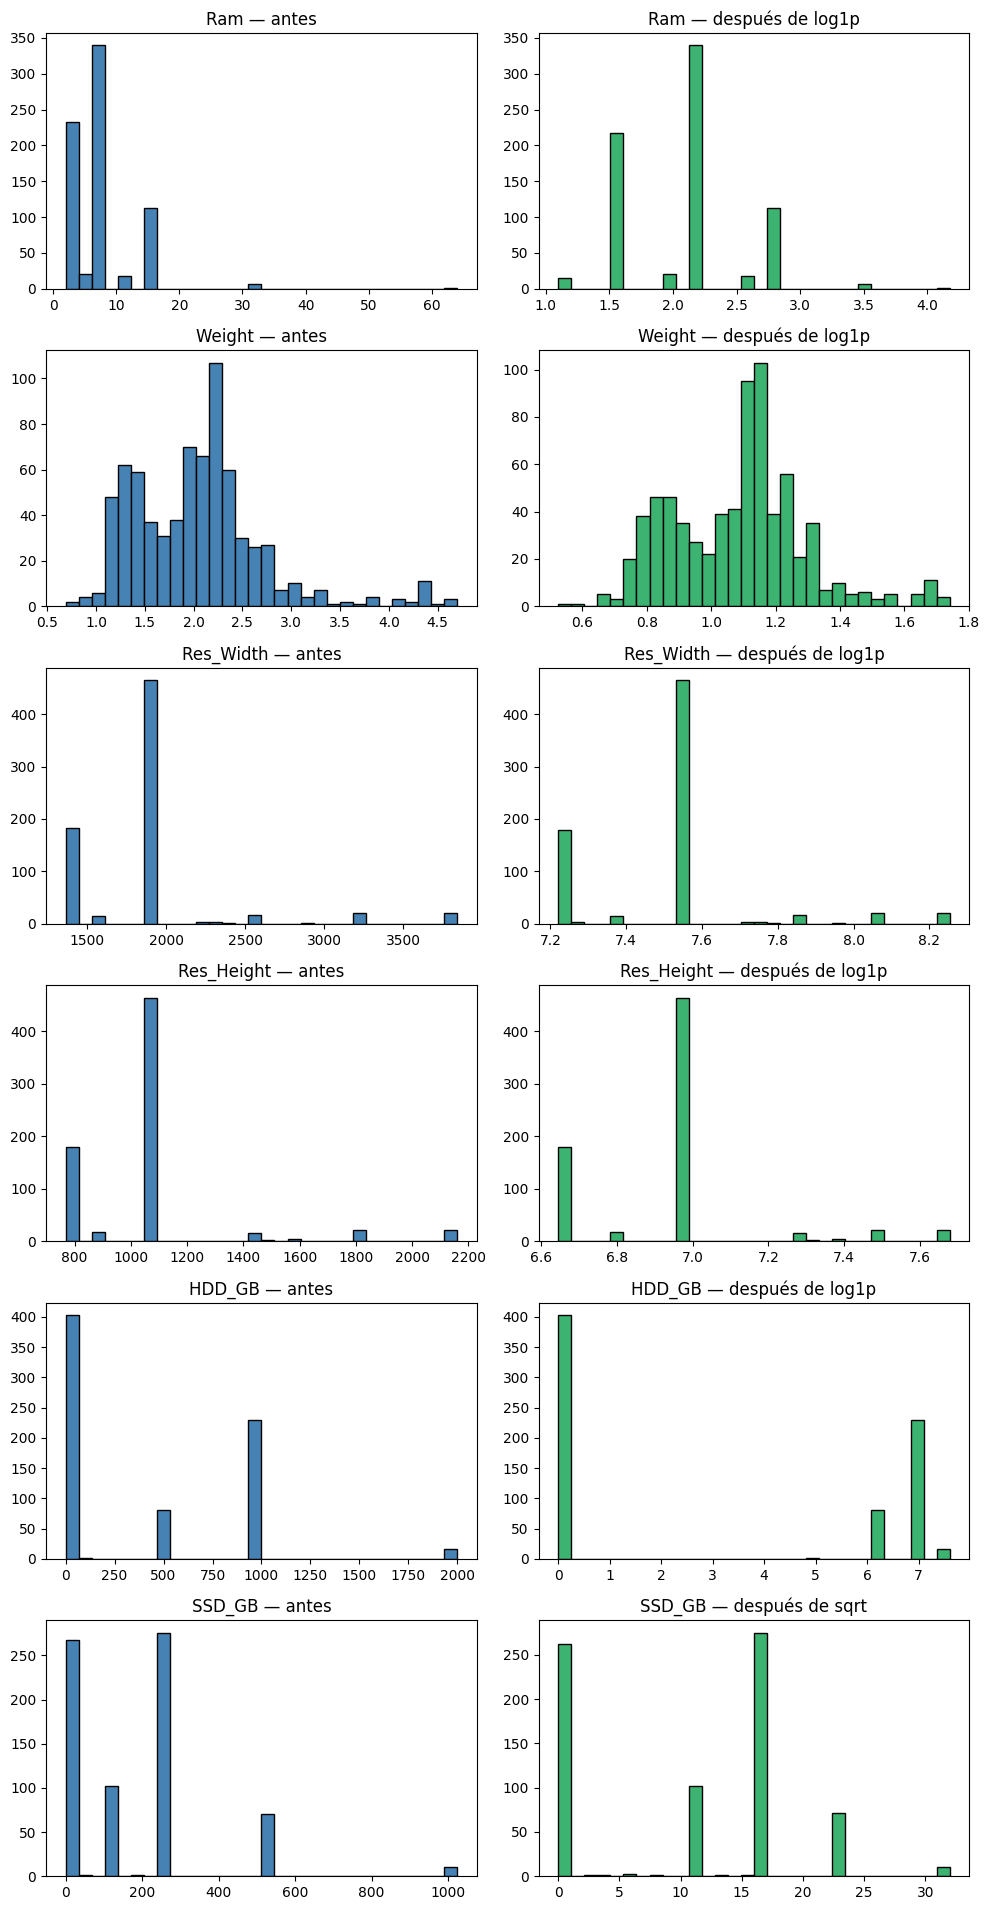

In [617]:
import matplotlib.pyplot as plt

cols_transformadas = [(c, "log1p") for c in log1p_cols] + [(c, "sqrt") for c in sqrt_cols]

fig, axes = plt.subplots(len(cols_transformadas), 2, figsize=(10, 3.2 * len(cols_transformadas)))

for row, (col, nombre_transf) in enumerate(cols_transformadas):
    axes[row, 0].hist(X_train_cat[col], bins=30, color='steelblue', edgecolor='black')
    axes[row, 0].set_title(f"{col} — antes")

    axes[row, 1].hist(X_train_final[col], bins=30, color='mediumseagreen', edgecolor='black')
    axes[row, 1].set_title(f"{col} — después de {nombre_transf}")

plt.tight_layout()
plt.show()

In [618]:
X_train_cat_sc, X_test_cat_sc = X_train_final.copy(), X_test_final.copy()
scaler_reg = StandardScaler()
X_train_cat_sc = scaler_reg.fit_transform(X_train_cat_sc)
X_test_cat_sc = scaler_reg.transform(X_test_cat_sc)

#### Comparativa de modelos por validación cruzada

Antes de comparar, generamos una versión escalada de los datos (`StandardScaler`, fit solo en train) — la necesitan KNN y Linear Regression, sensibles a la escala de las variables; los modelos de árbol (Random Forest, XGBoost, LightGBM, CatBoost) no la usan. Con eso, probamos varios algoritmos con 5-fold CV, comparando por RMSE (la métrica de la competición) y visualizando el resultado en un gráfico de barras horizontales con el error ± std del CV. Usamos `scoring='neg_root_mean_squared_error'` porque `cross_val_score` siempre maximiza la métrica internamente — para una métrica de error como el RMSE, sklearn la expone en negativo, y por eso negamos el resultado (`-scores.mean()`) al mostrarlo.

In [619]:
modelos_reg = {
    'KNN Regressor k=5  (baseline)     ': (KNeighborsRegressor(n_neighbors=5), X_train_cat_sc),
    'Decision Tree Regressor           ': (DecisionTreeRegressor(max_depth=5, random_state=42), X_train_cat),
    'Random Forest Regressor depth=5   ': (RandomForestRegressor(max_depth=5, n_estimators=100, random_state=42), X_train_cat),
    'Linear Regression                 ': (LinearRegression(), X_train_cat_sc),
    'XGBoost Regressor                 ': (XGBRegressor(max_depth=5, n_estimators=100, random_state=42), X_train_cat),
    'LightGBM Regressor                ': (LGBMRegressor(max_depth=5, n_estimators=100, random_state=42), X_train_cat),
    'CatBoost Regressor                ': (CatBoostRegressor(max_depth=5, n_estimators=100, random_state=42, verbose=0), X_train_cat),
}

In [620]:
scores_reg = {}
print('Modelo                             RMSE Media   +-Std')
print('-' * 55)
for nombre, (modelo, X_datos) in modelos_reg.items():
    scores = cross_val_score(
        modelo, X_datos, y_train,
        cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1
    )
    rmse_m = -scores.mean()
    rmse_s = scores.std()
    scores_reg[nombre] = (rmse_m, rmse_s, X_datos)
    print(f'{nombre}  {rmse_m:.4f}    {rmse_s:.4f}')

mejor_reg = min(scores_reg, key=lambda k: scores_reg[k][0])
print(f'\nMejor modelo: {mejor_reg.strip()}  RMSE={scores_reg[mejor_reg][0]:.4f}')


Modelo                             RMSE Media   +-Std
-------------------------------------------------------
KNN Regressor k=5  (baseline)       334.7787    82.7744
Decision Tree Regressor             367.8393    55.5911
Random Forest Regressor depth=5     316.1205    70.1008
Linear Regression                   454.8357    321.1158
XGBoost Regressor                   263.1049    62.7117
LightGBM Regressor                  293.6653    55.7402
CatBoost Regressor                  242.2190    56.9809

Mejor modelo: CatBoost Regressor  RMSE=242.2190


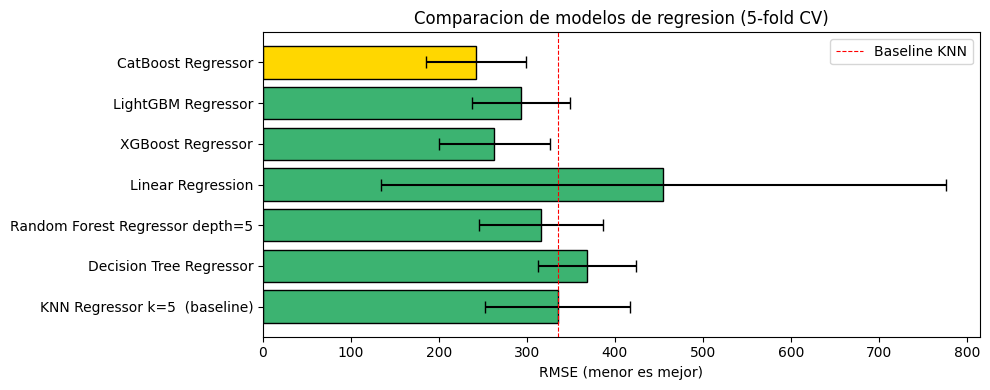

In [621]:
import matplotlib.pyplot as plt
nombres_r = [n.strip() for n in scores_reg.keys()]
mapas_m   = [v[0] for v in scores_reg.values()]
mapas_s   = [v[1] for v in scores_reg.values()]
colores_r = ['gold' if n == mejor_reg.strip() else 'mediumseagreen' for n in nombres_r]

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(nombres_r, mapas_m, xerr=mapas_s, color=colores_r, edgecolor='black', capsize=4)
ax.set_xlabel('RMSE (menor es mejor)')
ax.set_title('Comparacion de modelos de regresion (5-fold CV)')
ax.axvline(mapas_m[0], color='red', linestyle='--', linewidth=0.8, label='Baseline KNN')
ax.legend()
plt.tight_layout()
plt.show()

#### Optimización de hiperparámetros para el ganador (CatBoost)

CatBoost fue el modelo con menor RMSE en la comparativa anterior. `GridSearchCV`/`RandomizedSearchCV` prueban combinaciones de la grid (`depth`, `learning_rate`, `l2_leaf_reg`, `iterations`, `subsample`) por validación cruzada y se quedan con la que da mejor RMSE medio; no necesita escalado al ser un modelo de árbol.

La grid completa (768 combinaciones × 5 folds) es cara de ejecutar, y al principio ni siquiera paralelizaba bien: al `GridSearchCV` le faltaba `n_jobs=-1`, mientras cada fit de CatBoost ya usaba todos los núcleos internamente (`thread_count` por defecto) — eso satura la CPU con un solo fit a la vez en lugar de repartir muchos fits ligeros entre núcleos. La combinación correcta es `n_jobs=-1` en el buscador + `thread_count=1` en el modelo.

**Bootstrap (`bootstrap_type` / `bagging_temperature`):** además de la grid anterior, probamos cambiar el método de muestreo de filas en cada árbol. Por defecto CatBoost usa `MVS`; cambiarlo a `Bayesian` con `bagging_temperature=2` dio mejor resultado real en Kaggle que `MVS` y que otros valores de temperatura probados — `bagging_temperature=1`, pese a tener mejor pinta en local, resultó **9 puntos peor en Kaggle** que `temperature=2`. Esta es la configuración final.

**Lección de todo este proceso — la validación local no es del todo fiable en un dataset de solo 729 filas:** tres veces distintas (la densidad de píxeles `PPI`, la resolución como categoría en vez de `Res_Width`/`Res_Height`, y la temperatura del bootstrap) la validación local — split de test e incluso CV repetida (5 folds × 5 repeticiones) — señaló una mejora que **no se confirmó al subir la submission real a Kaggle**, llegando incluso a apuntar en la dirección contraria. Por eso, en decisiones de ajuste fino como estas, el criterio final es el resultado real en Kaggle y no solo el local — a diferencia de features con una historia clara detrás (`Cpu_Tier`, el desglose de GPU, `Product_Family`), que sí mejoraron de forma grande y consistente en ambas validaciones.

**Otras pruebas hechas y descartadas** (no llegaron a aplicarse, por no mejorar ni siquiera en local): entrenar sobre `log1p(Price_in_euros)` en vez del precio crudo (el log1p no afecta a modelos de árbol porque es una transformación monótona — no cambia los splits — y al deshacerla con `expm1` se introduce sesgo); y extraer el número de núcleos de CPU del texto (`"Dual Core"`/`"Quad Core"`) — solo aparece en el 10% de las filas, y ese 10% coincide exactamente con Celeron/Pentium, así que no aporta nada que `Cpu_Family` no capture ya.

Evaluamos el modelo ganador sobre el split de test local antes de reentrenar con todos los datos (sección 5).

In [622]:
# params_cat = {'depth': [2, 3, 5],
#           'learning_rate': [0.1, 0.2, 0.3],
#           'l2_leaf_reg': [1, 3, 5],
#           'iterations': [250, 500, 750],
#           'subsample': [0.4, 0.6, 0.8],
#           'min_data_in_leaf': [1, 3, 5, 10]
#           }

# cat_model = CatBoostRegressor(random_state=42, verbose=False, thread_count=1)
# gs_reg = GridSearchCV(
#     cat_model, params_cat,
#     cv=5, scoring='neg_root_mean_squared_error', verbose=0, n_jobs=-1
# )
# gs_reg.fit(X_train_cat, y_train)

# print('Mejores hiperparametros CatBoost Regressor:')
# print(gs_reg.best_params_)
# print(f'Mejor RMSE (CV): {-gs_reg.best_score_:.4f}')

Mejores hiperparametros CatBoost Regressor:
{'depth': 3, 'iterations': 500, 'l2_leaf_reg': 3, 'learning_rate': 0.2, 'subsample': 0.6}
Mejor RMSE (CV): 224.1923

In [623]:
# # params_xgb = {
# #     'n_estimators':  [100, 200, 400],
# #     'max_depth':     [3, 5, 7],
# #     'learning_rate': [0.05, 0.1, 0.2],
# #     'subsample':     [0.8, 1.0],
# # }
# params_xgb = {
#     'n_estimators':  [100, 200, 400, 600, 800, 1000],
#     'max_depth':     [3, 4, 5, 6],
#     'learning_rate': [0.05, 0.1, 0.2],
#     'subsample':     [0.6,0.8, 1.0],
# }
# xgb_model = XGBRegressor(random_state=42)
# gs_reg = GridSearchCV(
#     xgb_model, params_xgb,
#     cv=5, scoring='neg_root_mean_squared_error', verbose=0, n_jobs=-1
# )
# gs_reg.fit(X_train_cat, y_train)   # XGBoost no necesita escalado

# print('Mejores hiperparametros XGBoost Regressor:')
# print(gs_reg.best_params_)
# print(f'Mejor RMSE (CV): {-gs_reg.best_score_:.4f}')

Mejores hiperparametros XGBoost Regressor:
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 400, 'subsample': 0.8}
Mejor RMSE (CV): 267.1398

In [628]:
# cat_model = gs_reg.best_estimator_
cat_model = CatBoostRegressor(depth=3, iterations=500, l2_leaf_reg=3, learning_rate=0.2, random_state=42, 
                              bootstrap_type='Bayesian', bagging_temperature=2, verbose=False)
cat_model.fit(X_train_cat, y_train)
predictions_cat = cat_model.predict(X_test_cat)
rmse = root_mean_squared_error(y_test, predictions_cat)
print(f"RMSE: {rmse}")

RMSE: 240.94181234997518


## 5. Reentrenamiento sobre todos los datos de `train.csv`

Una vez afinado el modelo, reentrenamos con **todos** los datos disponibles antes de predecir sobre `test.csv`.

> ¿Por qué? El split anterior era solo para validar localmente. Para la submission final queremos aprovechar el 100% de los datos de entrenamiento.

Para eso releemos el CSV completo (no el split de la sección 2): a partir de aquí, `X_data`/`y_data` pasan a ser el "train" definitivo.

In [629]:
train_data = pd.read_csv('./data/train.csv', encoding='latin-1')
train_data.head()
X_data = train_data.drop(columns=['Price_in_euros']).copy()
y_data = train_data['Price_in_euros'].copy()
X_data.shape

(912, 12)

### 5.1 Repetimos el procesado de la sección 3 sobre `X_data` completo

Repetimos exactamente el mismo procesado de la sección 3 (resolución → peso/RAM → memoria → CPU → GPU → resto de categóricas), pero ahora sobre `X_data` completo, sin split. La diferencia clave: cada encoder se vuelve a **ajustar** aquí, porque `X_data` es ahora el "train" definitivo, y se guarda en el diccionario `encoders` para poder reutilizarlo (solo con `.transform()`) sobre `test.csv` en la sección 7. 

In [630]:
X_data_screen = add_screen_features(X_data)
X_data_screen.drop(columns="ScreenResolution", inplace=True)

X_data_weight = remove_text_numeric_col(X_data_screen, "Weight")
X_data_ram = remove_text_numeric_col(X_data_weight, "Ram")

X_data_memory = add_memory_features(X_data_ram)
X_data_memory.drop(columns="Memory", inplace=True)

X_data_cpu = add_cpu_features(X_data_memory)
encoders = {}
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoder.fit(X_data_cpu[["Cpu_Family", "Cpu_Tier"]])
encoders["Cpu"] = encoder

cpu_ohe_cols = encoder.get_feature_names_out(["Cpu_Family", "Cpu_Tier"])

X_data_cpu[cpu_ohe_cols] = encoder.transform(X_data_cpu[["Cpu_Family", "Cpu_Tier"]])
X_data_cpu.drop(columns=["Cpu", "Cpu_Family", "Cpu_Tier"], inplace=True)

X_data_gpu = X_data_cpu.copy()
X_data_gpu["Gpu"] = X_data_cpu["Gpu"].apply(classify_gpu)

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoder.fit(X_data_gpu[["Gpu"]])
encoders["Gpu"] = encoder

gpu_ohe_cols = encoder.get_feature_names_out(["Gpu"])
X_data_gpu[gpu_ohe_cols] = encoder.transform(X_data_gpu[["Gpu"]])
X_data_gpu.drop(columns=["Gpu"], inplace=True)

X_data_cat = X_data_gpu.copy()
rare_brands = X_data_cat["Company"].value_counts()[lambda x: x <= 2].index
encoders["rare_brands"] = rare_brands
X_data_cat["Company_grouped"] = X_data_cat["Company"].where(~X_data_cat["Company"].isin(rare_brands), "Other")
X_data_cat["OpSys_grouped"] = X_data_cat["OpSys"].replace({"Mac OS X": "macOS", "Windows 10 S": "Windows 10"})
X_data_cat["Product_Family"] = X_data_cat.apply(lambda r: extract_product_family(r["Product"], r["Company"]), axis=1)

for col in ["Company_grouped", "TypeName", "OpSys_grouped", "Product_Family"]:
    enc = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    enc.fit(X_data_cat[[col]])
    encoders[col] = enc

    ohe_cols = enc.get_feature_names_out([col])
    X_data_cat[ohe_cols] = enc.transform(X_data_cat[[col]])

X_data_cat.drop(columns=["Company","Company_grouped", "TypeName", "OpSys", "OpSys_grouped", "Product", "Product_Family"], inplace=True)
X_data_cat.set_index('laptop_ID', inplace=True)

X_data_cat.head()


,Inches,Ram,Weight,Res_Width,Res_Height,Is_IPS_Panel,Is_Touchscreen,Is_FullHD,Is_QuadHD,Is_4K,...,Product_Family_Swift,Product_Family_Tecra,Product_Family_ThinkPad,Product_Family_TravelMate,Product_Family_VivoBook,Product_Family_Vostro,Product_Family_XPS,Product_Family_Yoga,Product_Family_ZBook,Product_Family_ZenBook
laptop_ID,,,,,,,,,,,,,,,,,,,,,
755,15.6,8.0,1.86,1920,1080,0,0,1,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
618,15.6,16.0,2.59,1920,1080,0,0,1,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
909,15.6,8.0,2.04,1920,1080,0,0,1,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,13.3,8.0,1.34,1440,900,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
286,15.6,4.0,2.25,1920,1080,0,0,1,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### 5.2 Entrenamos el modelo final

Entrenamos el modelo ganador con los mismos hiperparámetros que obtuvo el GridSearch de la sección 4, ahora sobre el 100% de los datos (no necesita escalado, al ser un modelo de árbol). Por último, un chequeo rápido: predicciones sobre los propios datos de entrenamiento, que no se usan para nada más adelante — solo para confirmar que el modelo entrenado funciona antes de pasar a `test.csv`.

In [631]:
cat_model.fit(X_data_cat, y_data)

CatBoostRegressor(bagging_temperature=2, bootstrap_type='Bayesian', depth=3, iterations=500, l2_leaf_reg=3, learning_rate=0.2, loss_function='RMSE', random_state=42, verbose=False)

In [641]:
y_pred = cat_model.predict(X_data_cat)

---
# PARTE 2: Predicción y submission

Una vez tengas el modelo listo, toca predecir sobre `test.csv` y generar el archivo de submission.

## 6. Carga los datos de `test.csv`

`test.csv` tiene las mismas columnas que `train.csv` excepto `Price_in_euros` — esa es justamente la columna que hay que predecir.

In [633]:
X_data_test = pd.read_csv('./data/test.csv', encoding='latin-1')
X_data_test.shape

(391, 12)

## 7. Replica el procesado en `test.csv`

> ⚠️ Usa `.transform()`, **nunca `.fit_transform()`** sobre los datos de test.
>
> Lo único que **no puedes hacer** es eliminar filas.

Repetimos el mismo procesado de las secciones 3 y 5 (resolución → peso/RAM → memoria → CPU → GPU → resto de categóricas), pero aquí **solo transformamos**: todos los encoders ya estaban ajustados sobre `X_data` en la sección 5, y los recuperamos del diccionario `encoders`. En ningún momento se vuelve a llamar a `.fit()`.

In [634]:
X_data_test_screen = add_screen_features(X_data_test)
X_data_test_screen.drop(columns="ScreenResolution", inplace=True)

X_data_test_weight = remove_text_numeric_col(X_data_test_screen, "Weight")
X_data_test_ram = remove_text_numeric_col(X_data_test_weight, "Ram")

X_data_test_memory = add_memory_features(X_data_test_ram)
X_data_test_memory.drop(columns="Memory", inplace=True)

X_data_test_cpu = add_cpu_features(X_data_test_memory)
encoder = encoders["Cpu"]
cpu_ohe_cols = encoder.get_feature_names_out(["Cpu_Family", "Cpu_Tier"])

X_data_test_cpu[cpu_ohe_cols] = encoder.transform(X_data_test_cpu[["Cpu_Family", "Cpu_Tier"]])
X_data_test_cpu.drop(columns=["Cpu", "Cpu_Family", "Cpu_Tier"], inplace=True)

X_data_test_gpu = X_data_test_cpu.copy()
X_data_test_gpu["Gpu"] = X_data_test_cpu["Gpu"].apply(classify_gpu)

encoder = encoders["Gpu"]
gpu_ohe_cols = encoder.get_feature_names_out(["Gpu"])
X_data_test_gpu[gpu_ohe_cols] = encoder.transform(X_data_test_gpu[["Gpu"]])
X_data_test_gpu.drop(columns=["Gpu"], inplace=True)

X_data_test_cat = X_data_test_gpu.copy()
rare_brands = encoders["rare_brands"]
X_data_test_cat["Company_grouped"] = X_data_test_cat["Company"].where(~X_data_test_cat["Company"].isin(rare_brands), "Other")
X_data_test_cat["OpSys_grouped"] = X_data_test_cat["OpSys"].replace({"Mac OS X": "macOS", "Windows 10 S": "Windows 10"})
X_data_test_cat["Product_Family"] = X_data_test_cat.apply(lambda r: extract_product_family(r["Product"], r["Company"]), axis=1)

for col in ["Company_grouped", "TypeName", "OpSys_grouped", "Product_Family"]:
    encoder = encoders[col]
    cpu_ohe_cols = encoder.get_feature_names_out([col])
    X_data_test_cat[cpu_ohe_cols] = encoder.transform(X_data_test_cat[[col]])

X_data_test_cat.drop(columns=["Company","Company_grouped", "TypeName", "OpSys", "OpSys_grouped", "Product", "Product_Family"], inplace=True)
X_data_test_cat.set_index('laptop_ID', inplace=True)

X_data_test_cat.head()

,Inches,Ram,Weight,Res_Width,Res_Height,Is_IPS_Panel,Is_Touchscreen,Is_FullHD,Is_QuadHD,Is_4K,...,Product_Family_Swift,Product_Family_Tecra,Product_Family_ThinkPad,Product_Family_TravelMate,Product_Family_VivoBook,Product_Family_Vostro,Product_Family_XPS,Product_Family_Yoga,Product_Family_ZBook,Product_Family_ZenBook
laptop_ID,,,,,,,,,,,,,,,,,,,,,
209,15.6,16.0,2.400,1920,1080,0,0,1,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1281,15.6,4.0,2.400,1366,768,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1168,15.6,4.0,1.900,1366,768,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1231,15.6,8.0,2.191,1920,1080,1,1,1,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1020,14.0,4.0,1.950,1920,1080,0,0,1,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [635]:
pred_submit = cat_model.predict(X_data_test_cat)

## 8. Genera la submission

Con el modelo ya reentrenado y el `test.csv` procesado, generamos las predicciones finales (`pred_submit`) y las convertimos en el archivo que se sube a Kaggle.

### 8.1 ¿Qué formato espera Kaggle?

`sample_submission.csv` define el formato exacto que espera Kaggle: columnas `laptop_ID` + `Price_in_euros`, en el mismo orden de filas que `test.csv`.

In [636]:
sample = pd.read_csv('./data/sample_submission.csv', encoding='latin-1')
sample.head()

,laptop_ID,Price_in_euros
0,209,1949.1
1,1281,805.0
2,1168,1101.0
3,1231,1293.8
4,1020,1832.6


### 8.2 Crea tu submission

Construimos la submission con los mismos `laptop_ID` y el mismo orden que `sample_submission`, emparejados con nuestras predicciones.

In [637]:
sample_submission = pd.read_csv('./data/sample_submission.csv')
sample_submission.head()
ids = sample_submission["laptop_ID"]
primer_submit = pd.DataFrame({"laptop_ID": ids, "Price_in_euros": pred_submit})
primer_submit.head()

,laptop_ID,Price_in_euros
0,209,1517.027342
1,1281,293.264034
2,1168,319.735627
3,1231,968.081721
4,1020,974.736127


### 8.3 Chequeador

Pásale el chequeador antes de subir a Kaggle. Si todo está bien, guardará el CSV automáticamente con un nombre único.

In [638]:
def checker(df_to_submit, sample, filename=None):
    """
    Valida que tu submission tenga la forma requerida por Kaggle.
    Si es correcta, guarda el CSV listo para subir.
    Si no, lee el mensaje de error y corrígelo.
    """
    if df_to_submit.shape != sample.shape:
        print(' Shape incorrecto.')
        print(f'   Tu submission: {df_to_submit.shape} | Esperado: {sample.shape}')
        print('   Revisa que no hayas borrado filas del test ni añadido/quitado columnas.')
        return

    if not (df_to_submit.columns == sample.columns).all():
        print(' Nombres de columnas incorrectos.')
        print(f'   Tus columnas:       {list(df_to_submit.columns)}')
        print(f'   Columnas esperadas: {list(sample.columns)}')
        return

    if not (df_to_submit['laptop_ID'] == sample['laptop_ID']).all():
        print(' Los IDs no coinciden con sample_submission. Revisa que no hayas reordenado el test.csv.')
        return

    if filename is None:
        from datetime import datetime
        timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
        filename = f'submission_{timestamp}.csv'

    df_to_submit.to_csv(filename, index=False)
    print(f" ¡Todo correcto! Submission guardada como '{filename}'. ¡A Kaggle!")

In [639]:
checker(primer_submit, sample_submission, filename='submission/submission_CatBoost_Bayesian_def.csv')

 ¡Todo correcto! Submission guardada como 'submission/submission_CatBoost_Bayesian_def.csv'. ¡A Kaggle!
